# Examining Eta1 Pic

In [1]:
import os
os.chdir('../scripts/')
from analysis_tools_cython import *
from astropy.timeseries import LombScargle
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['figure.figsize'] = (15, 6)
import lightkurve as lk

## Functions

In [2]:
def ls_filter(time,flux,min_score):
    """Also removes periodic noise, using lomb scargle methods."""
    period = time[-1]-time[0] # length of observation (size of sampling interval)
    N = len(time)
    nyquist_period = (2*period)/N

    min_freq = 1/period # Need at least two sampled points in every period you want to capture
    nyquist_freq = N/(2*period) 
    flux_real = flux.copy()
    for _ in range(30):
        ls = LombScargle(time.data,flux_real.data)
        freq,powers = ls.autopower(method='fast',minimum_frequency=min_freq,maximum_frequency=nyquist_freq,samples_per_peak=10)
        i = np.argmax(powers)
        if powers[i] < min_score:
            break

        flux_real -= ls.model(time,freq[i])
    
        del ls
    return flux_real

---

## The Eta1 Pictoris lightcurve

### S5

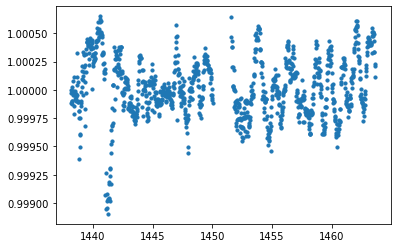

In [3]:
s5_clean, info = import_lightcurve('/storage/tess/spoc_full_cadence/S05/target/0000/0002/1936/7750/hlsp_tess-spoc_tess_phot_0000000219367750-s0005_tess_v1_lc.fits',flux='PDCSAP_FLUX',pipeline='spoc',drop_bad_points=False)
plt.scatter(s5_clean['TIME'],s5_clean['PDCSAP_FLUX']/np.nanmedian(s5_clean['PDCSAP_FLUX']),s=10)

## The Beta Pic lightcurve

In [4]:
bpic, bpic_info = import_lightcurve('/storage/tess/spoc_full_cadence/S06/target/0000/0002/7057/7175/hlsp_tess-spoc_tess_phot_0000000270577175-s0006_tess_v1_lc.fits',flux='PDCSAP_FLUX',pipeline='spoc')
freq, powers = LombScargle(bpic['TIME'],bpic['PDCSAP_FLUX']).autopower()

---

## Eta1 Pic periodogram

In [5]:
freq2, powers2 = LombScargle(s5_clean['TIME'],s5_clean['PDCSAP_FLUX']).autopower()

Text(0.5, 1.0, 'eta1 pic')

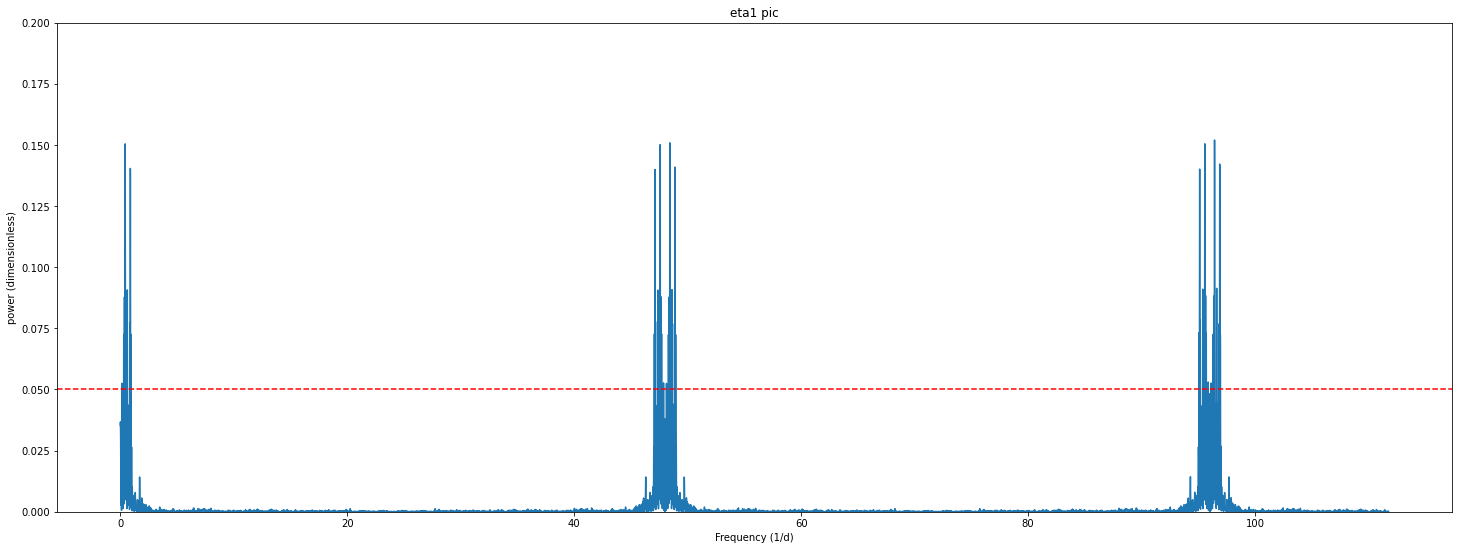

In [6]:
plt.figure(figsize=(25,9))
plt.plot(freq2,powers2)
plt.ylim([0,0.2])
plt.axhline(0.05,c='red',linestyle='--')
plt.xlabel('Frequency (1/d)')
plt.ylabel('power (dimensionless)')
plt.title('eta1 pic')

## Detrend Eta1 Pic

### Base lightcurve

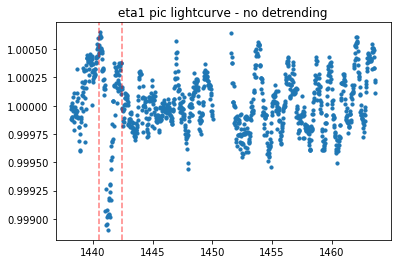

In [7]:
s5_clean, _ = import_lightcurve('/storage/tess/spoc_full_cadence/S05/target/0000/0002/1936/7750/hlsp_tess-spoc_tess_phot_0000000219367750-s0005_tess_v1_lc.fits',flux='PDCSAP_FLUX',pipeline='spoc',drop_bad_points=True)
plt.scatter(s5_clean['TIME'],s5_clean['PDCSAP_FLUX']/np.nanmedian(s5_clean['PDCSAP_FLUX']),s=10)
plt.axvline(1440.5,linestyle='--',color='red',alpha=0.5)
plt.axvline(1442.4,linestyle='--',color='red',alpha=0.5)
plt.title('eta1 pic lightcurve - no detrending')
plt.show()

### 0.1 power

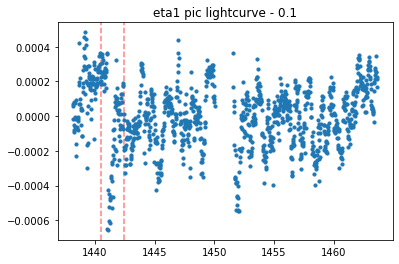

In [8]:
freq, powers = LombScargle(s5_clean['TIME'],s5_clean['PDCSAP_FLUX']).autopower()
flux_real01 = ls_filter(s5_clean['TIME'],normalise_flux(s5_clean['PDCSAP_FLUX']),0.1)
plt.scatter(s5_clean['TIME'],flux_real01,s=10,zorder=5)
plt.axvline(1440.5,linestyle='--',color='red',alpha=0.5)
plt.axvline(1442.4,linestyle='--',color='red',alpha=0.5)
plt.title('eta1 pic lightcurve - 0.1')

plt.show()

### 0.07 power

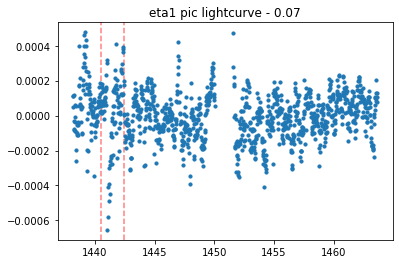

In [9]:
freq, powers = LombScargle(s5_clean['TIME'],s5_clean['PDCSAP_FLUX']).autopower()
flux_real07 = ls_filter(s5_clean['TIME'],normalise_flux(s5_clean['PDCSAP_FLUX']),0.07)
plt.scatter(s5_clean['TIME'],flux_real07,s=10,zorder=5)
plt.axvline(1440.5,linestyle='--',color='red',alpha=0.5)
plt.axvline(1442.4,linestyle='--',color='red',alpha=0.5)
plt.title('eta1 pic lightcurve - 0.07')

plt.show()

### Summing them up into one plot

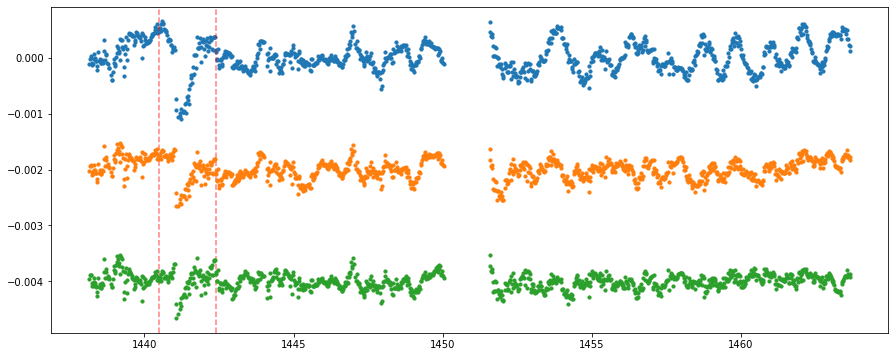

In [10]:
plt.figure(figsize=(15,6))
plt.scatter(s5_clean['TIME'],s5_clean['PDCSAP_FLUX']/np.nanmedian(s5_clean['PDCSAP_FLUX'])-np.ones(len(s5_clean)),s=10)
plt.scatter(s5_clean['TIME'],flux_real01-0.002,s=10,zorder=5)
plt.scatter(s5_clean['TIME'],flux_real07-0.004,s=10,zorder=5)
plt.axvline(1440.5,linestyle='--',color='red',alpha=0.5)
plt.axvline(1442.4,linestyle='--',color='red',alpha=0.5)
plt.show()

### Calculate test statistic for bottom one

In [11]:
table = Table([s5_clean['TIME'],flux_real07,s5_clean['QUALITY'],s5_clean['PDCSAP_FLUX_ERR']],names=['time','flux','quality','real'])
t, flux, quality, real, flux_error = clean_data(table)
flux *= real
timestep = calculate_timestep(table)
factor = ((1/48)/timestep)

In [12]:
m,n,T1,minT,minT_time,minT_duration,Tm_start,Tm_end,Tm_depth,Ts = run_test_statistic(flux, factor, timestep,t)

In [13]:
minT/Ts

-3.620809724432397

hmm.

## Smoothing

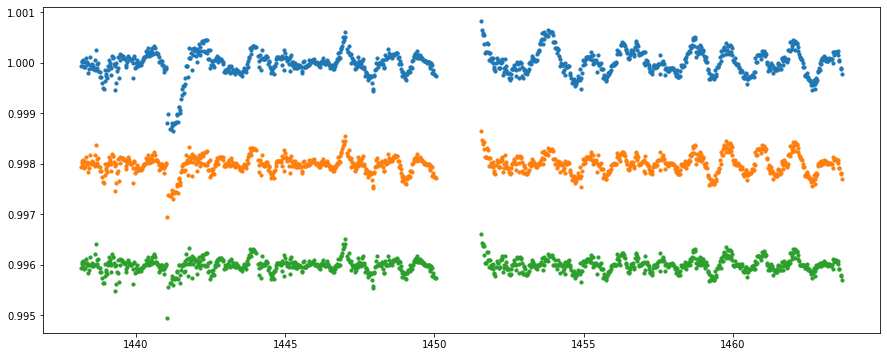

In [14]:
smooth_flux, trend = smoothing(s5_clean,method='median',window_length=2.5)
smooth_flux1, trend = smoothing(s5_clean,method='median',window_length=1)
smooth_flux2, trend = smoothing(s5_clean,method='median',window_length=0.8)

plt.figure(figsize=(15,6))
plt.scatter(s5_clean['TIME'],smooth_flux,s=10)
plt.scatter(s5_clean['TIME'],smooth_flux1-0.002,s=10)
plt.scatter(s5_clean['TIME'],smooth_flux2-0.004,s=10)

## Eta2 Pic

---

## Alpha Pic

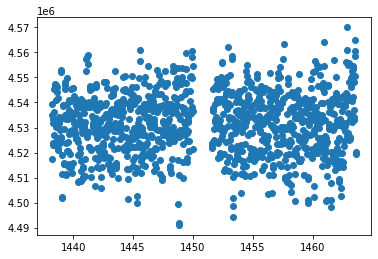

In [15]:
alphapic, _ = import_lightcurve('/storage/tess/spoc_full_cadence/S05/target/0000/0001/6760/2316/hlsp_tess-spoc_tess_phot_0000000167602316-s0005_tess_v1_lc.fits',flux='PDCSAP_FLUX',pipeline='spoc')
plt.scatter(alphapic['TIME'],alphapic['PDCSAP_FLUX'])

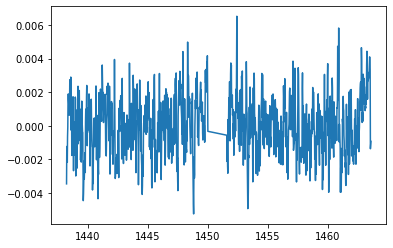

In [21]:
freq, powers = LombScargle(alphapic['TIME'],alphapic['PDCSAP_FLUX']).autopower()
flux_real = ls_filter(alphapic['TIME'],alphapic['PDCSAP_FLUX']/np.nanmedian(alphapic['PDCSAP_FLUX']),0.05)
plt.plot(alphapic['TIME'],flux_real)

---

## Gamma Pic

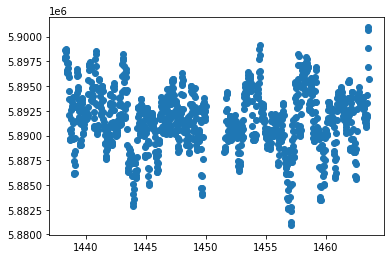

In [18]:
gammapic, _ = import_lightcurve('/storage/tess/spoc_full_cadence/S05/target/0000/0003/5061/9228/hlsp_tess-spoc_tess_phot_0000000350619228-s0005_tess_v1_lc.fits',flux='PDCSAP_FLUX',pipeline='spoc')
plt.scatter(gammapic['TIME'],gammapic['PDCSAP_FLUX'])

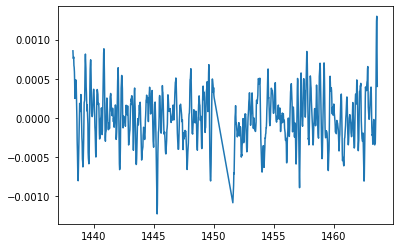

In [20]:
freq, powers = LombScargle(alphapic['TIME'],alphapic['PDCSAP_FLUX']).autopower()
flux_real = ls_filter(gammapic['TIME'],gammapic['PDCSAP_FLUX']/np.nanmedian(gammapic['PDCSAP_FLUX']),0.05)
plt.plot(gammapic['TIME'],flux_real)

---
## 2-min SPOC lightcurve for Eta1 Pic

Going to bin a 2-minute lightcurve to 30 minutes to see if we can replicate the results above

In [22]:
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
import xrpdata

In [23]:
etapic = lk.search_lightcurve('Eta1 Pic',author='SPOC')[1].download()
etapic_copy = etapic[etapic['quality'] == 0]

In [24]:
bin_time = 30/24/60

In [25]:
etapic_binned = etapic.bin(bin_time)
etapic_copy_binned = etapic_copy.bin(bin_time)

In [26]:
print(len(etapic_binned))
print(len(etapic_copy_binned))

1263
1233


In [27]:
bad_times = xrpdata.load_bad_times()
bad_times = bad_times - 2457000

# # loading MAD 
mad_df = xrpdata.load_mad()
sec = 5
camera = 3

mad_arr = mad_df.loc[:len(etapic_binned)-1,f"{sec}-{camera}"]
sig_clip = sigma_clip(mad_arr,sigma=3,masked=True)

# # applied MAD cut to keep points within selected sigma
mad_cut = mad_arr.values < ~sig_clip.mask 

# # return indices of values above MAD threshold
matched_ind = np.where(~mad_cut) # indices of MAD's above threshold

# # Change quality of matched indices to 2**(17-1) (or add 2**(17-1) if existing flag already present)
etapic_binned['quality'][matched_ind] += 2**(17-1)
etapic_binned['quality'] = etapic_binned['quality'].astype(np.int32) # int32 set so it can work with `get_quality_indices` function

# # Ethan Kruse bad time mask
mask = np.ones_like(etapic_binned['time'], dtype=bool)
for i in bad_times:
    newchunk = (etapic_binned['time'].value<i[0])|(etapic_binned['time'].value>i[1])
    mask = mask & newchunk

# # Apply Kruse bad mask to table
#etapic_binned = etapic_binned[mask]

# return table

In [32]:
etapic_copy_binned_copy = etapic_binned[etapic_binned['quality'] == 0]

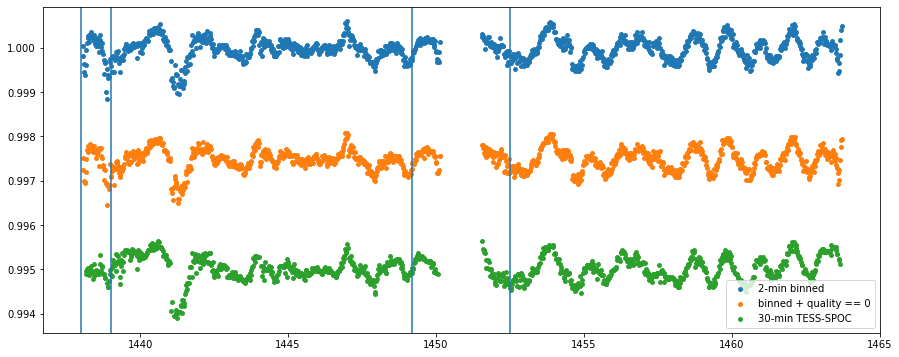

In [33]:
plt.figure(figsize=(15,6))
plt.scatter(etapic_binned['time'].value,etapic_binned['flux'].value/np.nanmedian(etapic_binned['flux'].value),s=15,label='2-min binned')
plt.scatter(etapic_copy_binned['time'].value,etapic_copy_binned['flux'].value/np.nanmedian(etapic_copy_binned['flux'].value)-0.0025,s=15,label='binned + quality == 0')
#plt.scatter(etapic_copy_binned_copy['time'].value,etapic_copy_binned_copy['flux'].value/np.nanmedian(etapic_copy_binned_copy['flux'].value)-0.005,s=15,label='binned + quality == 0 + MAD applied')
plt.axvline(1438)
plt.axvline(1439)
plt.axvline(1449.2)
plt.axvline(1452.5)
#plt.scatter(etapic_copy_binned[etapic_copy_binned['quality'] != 0]['time'].value,etapic_copy_binned[etapic_copy_binned['quality'] != 0]['flux'].value/np.nanmedian(etapic_copy_binned_copy['flux'].value)-0.005,s=15,label='binned + quality == 0 + MAD applied',color='black')

plt.scatter(s5_clean['TIME'],s5_clean['PDCSAP_FLUX']/np.nanmedian(s5_clean['PDCSAP_FLUX'])-0.005,s=15,label='30-min TESS-SPOC')
plt.legend()

---

In [34]:
from astropy.table import Table

In [35]:
etapic_clean = etapic_copy_binned[etapic_copy_binned['time'].value > 1439].to_table()

In [36]:
freq, powers = LombScargle(etapic_clean['time'].value,etapic_clean['flux'].value).autopower()
flux_real01 = ls_filter(etapic_clean['time'].value,normalise_flux(etapic_clean['flux'].value),0.1)
flux_real07 = ls_filter(etapic_clean['time'].value,normalise_flux(etapic_clean['flux'].value),0.07)

In [37]:
table = Table([etapic_clean['time'].value,flux_real07,etapic_clean['quality'].value,etapic_clean['pdcsap_flux_err'].value],names=['time','flux','quality','real'])
t, flux, quality, real, flux_error = clean_data(table)
flux *= real
timestep = calculate_timestep(table)
factor = ((1/48)/timestep)

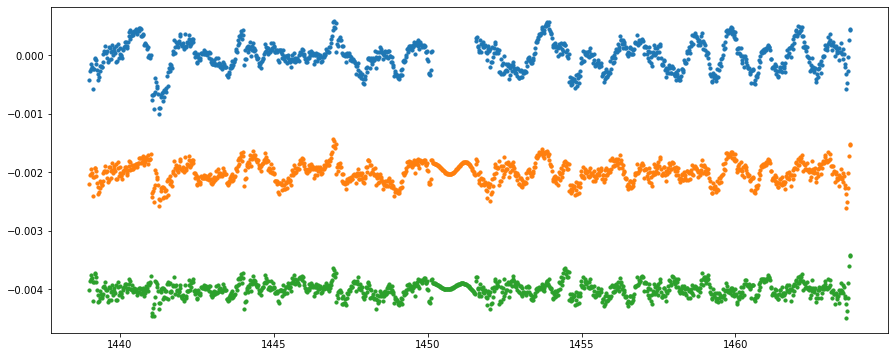

In [38]:
plt.figure(figsize=(15,6))
plt.scatter(etapic_clean['time'].value,etapic_clean['flux'].value/np.nanmedian(etapic_clean['flux'].value)-np.ones(len(etapic_clean)),s=10)
plt.scatter(t,flux_real01-0.002,s=10)
plt.scatter(t,flux-0.004,s=10,zorder=5)

This lightcurve is with `quality==0`. Last test is to relax this criterion and see what we come up with.

## Eta1 Pic (with non-zero quality flags)

In [39]:
freq, powers = LombScargle(etapic_binned['time'].value,etapic_binned['flux'].value).autopower()
flux_real01 = ls_filter(etapic_binned['time'].value,normalise_flux(etapic_binned['flux'].value),0.1)
flux_real07 = ls_filter(etapic_binned['time'].value,normalise_flux(etapic_binned['flux'].value),0.07)

In [40]:
table = Table([etapic_binned['time'].value,flux_real07,etapic_binned['quality'].value,etapic_binned['pdcsap_flux_err'].value],names=['time','flux','quality','real'])
t, flux, quality, real, flux_error = clean_data(table)
flux *= real
timestep = calculate_timestep(table)
factor = ((1/48)/timestep)

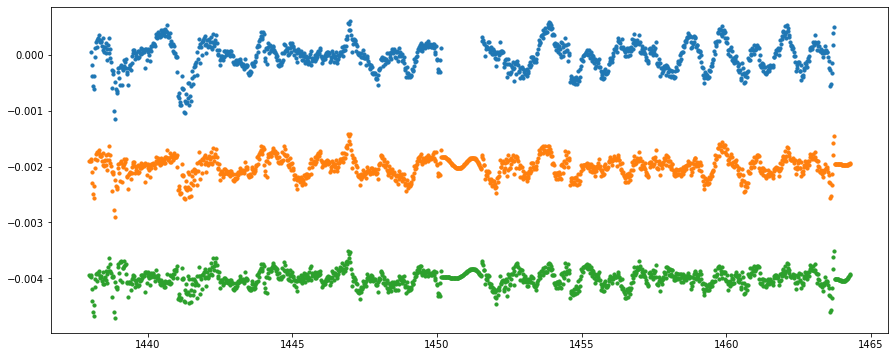

In [41]:
plt.figure(figsize=(15,6))
plt.scatter(etapic_binned['time'].value,etapic_binned['flux'].value/np.nanmedian(etapic_binned['flux'].value)-np.ones(len(etapic_binned)),s=10)
plt.scatter(t,flux_real01-0.002,s=10)
plt.scatter(t,flux-0.004,s=10,zorder=5)

----

## Binning Beta Pic and doing a Fourier subtraction

In [59]:
betapic = lk.search_lightcurve('Beta Pic',author='SPOC')[2].download()

In [60]:
betapic_binned = betapic_copy.bin(bin_time)

In [61]:
freq_bp, powers_bp = LombScargle(betapic_binned['time'].value,betapic_binned['flux'].value).autopower()
flux_real01_bp = ls_filter(betapic_binned['time'].value,normalise_flux(betapic_binned['flux'].value),0.1)
flux_real07_bp = ls_filter(betapic_binned['time'].value,normalise_flux(betapic_binned['flux'].value),0.07)
flux_real05_bp = ls_filter(betapic_binned['time'].value,normalise_flux(betapic_binned['flux'].value),0.05)

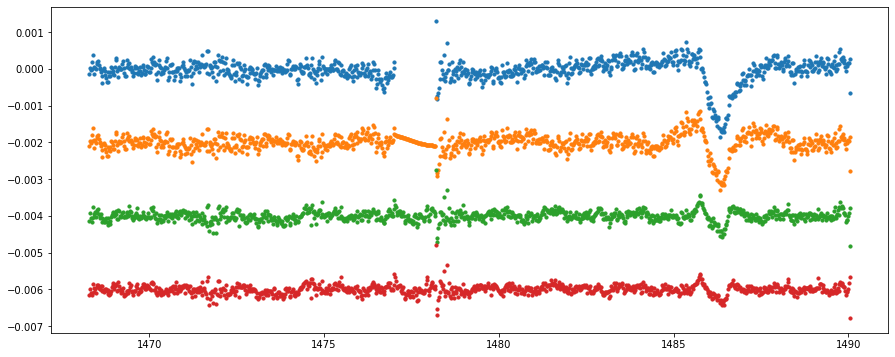

In [62]:
plt.figure(figsize=(15,6))
plt.scatter(betapic_binned['time'].value,betapic_binned['flux'].value/np.nanmedian(betapic_binned['flux'].value)-np.ones(len(betapic_binned)),s=10)
plt.scatter(betapic_binned['time'].value,flux_real01_bp-0.002,s=10)
plt.scatter(betapic_binned['time'].value,flux_real07_bp-0.004,s=10,zorder=5)
plt.scatter(betapic_binned['time'].value,flux_real05_bp-0.006,s=10,zorder=5)

---
### The 30-minute TESS-SPOC lightcurve

In [63]:
betapic_lc = lk.search_lightcurve('Beta Pic',author='TESS-SPOC')[2].download()
betapic_copy = betapic[betapic['quality'] == 0]

In [64]:
freq_bp, powers_bp = LombScargle(betapic_lc['time'].value,betapic_lc['flux'].value).autopower()
flux_real01_bp = ls_filter(betapic_lc['time'].value,normalise_flux(betapic_lc['flux'].value),0.1)
flux_real07_bp = ls_filter(betapic_lc['time'].value,normalise_flux(betapic_lc['flux'].value),0.07)
flux_real05_bp = ls_filter(betapic_lc['time'].value,normalise_flux(betapic_lc['flux'].value),0.05)

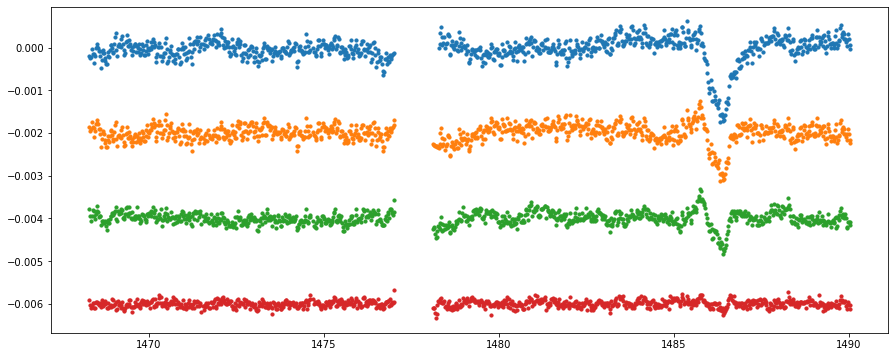

In [65]:
plt.figure(figsize=(15,6))
plt.scatter(betapic_lc['time'].value,betapic_lc['flux'].value/np.nanmedian(betapic_lc['flux'].value)-np.ones(len(betapic_lc)),s=10)
plt.scatter(betapic_lc['time'].value,flux_real01_bp-0.002,s=10)
plt.scatter(betapic_lc['time'].value,flux_real07_bp-0.004,s=10,zorder=5)
plt.scatter(betapic_lc['time'].value,flux_real05_bp-0.006,s=10,zorder=5)